# Gradient Boosting Model for Delinquency Prediction

Uses the **top 50 selected features** from the comprehensive feature selection pipeline.

- Train / Validation / Test split (60/20/20)
- `GradientBoostingClassifier` (scikit-learn)
- Handles class imbalance via `sample_weight`
- No feature scaling required (tree-based model)
- **Optuna** (TPE sampler) for hyperparameter search
- Records training time, scoring time, ROC-AUC, and Average Precision

In [1]:
import sys
import pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_curve,
)
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from scripts.model_data import load_and_split

## 1. Load Data & Selected Features

In [2]:
# ── Configuration ────────────────────────────────────────────────
N_FEATURES = 125  # ← change this to use a different number of top-ranked features
FEATURES_FILE = "filtered_features_consensus_ordered.csv"

# Load features and perform 60/20/20 stratified split
X_train, X_val, X_test, y_train, y_val, y_test, available_features, features_df = \
    load_and_split(n_features=N_FEATURES, features_filename=FEATURES_FILE)

print(f'Features used:  {len(available_features)}')
print(f'Train:          {X_train.shape}  |  positives: {y_train.sum()} ({100*y_train.mean():.1f}%)')
print(f'Validation:     {X_val.shape}  |  positives: {y_val.sum()} ({100*y_val.mean():.1f}%)')
print(f'Test:           {X_test.shape}  |  positives: {y_test.sum()} ({100*y_test.mean():.1f}%)')

Features  : 125 (top-125)
Samples   : 10754  |  DQ rate: 8.18%
Train     : 6452  (8.18% positive)
Val       : 2151  (8.18% positive)
Test      : 2151  (8.18% positive)
Features used:  125
Train:          (6452, 125)  |  positives: 528 (8.2%)
Validation:     (2151, 125)  |  positives: 176 (8.2%)
Test:           (2151, 125)  |  positives: 176 (8.2%)


## 2. Class Imbalance Weights

`GradientBoostingClassifier` does not have a `class_weight` parameter, so we pass per-sample weights directly to `fit()`.

In [3]:
n_neg = int(np.sum(y_train == 0))
n_pos = int(np.sum(y_train == 1))
scale_pos_weight = n_neg / n_pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}  (neg={n_neg}, pos={n_pos})')

# Build per-sample weight array (minority class gets higher weight)
sample_weight_train = np.where(y_train == 1, scale_pos_weight, 1.0)

scale_pos_weight: 11.22  (neg=5924, pos=528)


## 3. Baseline Model

Quick sanity-check with default-ish parameters before tuning.

In [4]:
baseline = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=50,
    random_state=42,
    verbose=0,
)

print('Training baseline model…')
t0 = time.time()
baseline.fit(X_train, y_train, sample_weight=sample_weight_train)
t_baseline = time.time() - t0

baseline_val_auc = roc_auc_score(y_val, baseline.predict_proba(X_val)[:, 1])
print(f'Baseline trained in {t_baseline:.1f}s')
print(f'Baseline Val AUC : {baseline_val_auc:.4f}')

Training baseline model…
Baseline trained in 25.5s
Baseline Val AUC : 0.7811


## 4. Hyperparameter Tuning with Optuna

Search over the key knobs for `GradientBoostingClassifier`:

| Parameter | Controls |
|---|---|
| `max_depth` | Tree complexity |
| `learning_rate` | Shrinkage per tree |
| `subsample` | Stochastic gradient boosting fraction |
| `min_samples_leaf` | Minimum leaf size (regularisation) |
| `min_samples_split` | Minimum split size |
| `max_features` | Feature fraction per split |
| `n_iter_no_change` | Early stopping patience |

In [5]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 60  # increase for a more thorough search

def objective(trial):
    params = dict(
        n_estimators      = 1000,          # high; early stopping controls actual count
        max_depth         = trial.suggest_int('max_depth', 2, 6),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 10, 100),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 40),
        max_features      = trial.suggest_float('max_features', 0.3, 1.0),
        n_iter_no_change  = trial.suggest_int('n_iter_no_change', 10, 40),
        validation_fraction = 0.0,         # we supply our own val set via warm-start scoring
        tol               = 1e-4,
        random_state      = 42,
        verbose           = 0,
    )

    # sklearn GBM early-stopping requires validation_fraction > 0
    # Instead, combine train+val and use n_iter_no_change on the val score manually
    params['validation_fraction'] = 0.2   # held-out slice inside train

    model = GradientBoostingClassifier(**params)
    model.fit(X_train, y_train, sample_weight=sample_weight_train)

    val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    return val_auc

sampler = optuna.samplers.TPESampler(seed=42)
pruner  = optuna.pruners.MedianPruner(n_warmup_steps=10)
study   = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)

print(f'Running Optuna search ({N_TRIALS} trials) …')
t_tune = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Search finished in {time.time() - t_tune:.1f}s')
print(f'\nBest val AUC : {study.best_value:.4f}')
print(f'Best params  :')
for k, v in study.best_params.items():
    print(f'  {k:<25} {v}')

Running Optuna search (60 trials) …


  0%|          | 0/60 [00:00<?, ?it/s]

Search finished in 315.3s

Best val AUC : 0.7853
Best params  :
  max_depth                 5
  learning_rate             0.01705874212091073
  subsample                 0.6549677806349168
  min_samples_leaf          94
  min_samples_split         6
  max_features              0.9233666284029042
  n_iter_no_change          36


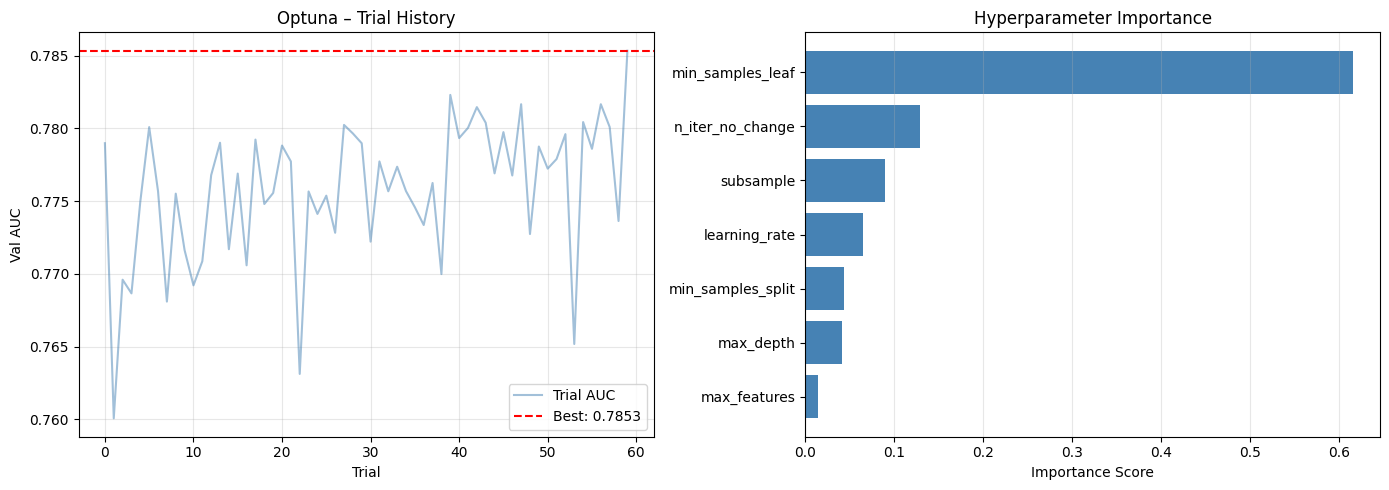

In [6]:
# ── Optuna visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trial AUC history
trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_values, alpha=0.5, color='steelblue', label='Trial AUC')
axes[0].axhline(study.best_value, color='red', linestyle='--',
                label=f'Best: {study.best_value:.4f}')
axes[0].set(title='Optuna – Trial History', xlabel='Trial', ylabel='Val AUC')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Parameter importance
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys())[::-1], list(importances.values())[::-1], color='steelblue')
axes[1].set(title='Hyperparameter Importance', xlabel='Importance Score')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Train Final Model with Best Hyperparameters

In [7]:
best_params = dict(
    n_estimators        = 1000,
    validation_fraction = 0.2,
    tol                 = 1e-4,
    random_state        = 42,
    verbose             = 1,
    **study.best_params,
)

print(f'Training final Gradient Boosting with best params (top-{N_FEATURES} features)…')
t0 = time.time()
model = GradientBoostingClassifier(**best_params)
model.fit(X_train, y_train, sample_weight=sample_weight_train)
training_time = time.time() - t0

print(f'\nTraining completed in {training_time:.2f}s  ({training_time/60:.2f} min)')
print(f'Actual n_estimators used : {model.n_estimators_}')

Training final Gradient Boosting with best params (top-125 features)…
      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.3741           0.0091           52.00s
         2           1.3635           0.0111           52.66s
         3           1.3549           0.0111           53.41s
         4           1.3431           0.0079           51.93s
         5           1.3329           0.0090           52.43s
         6           1.3200           0.0042           52.67s
         7           1.3136           0.0139           53.37s
         8           1.3040           0.0102           53.50s
         9           1.2970           0.0124           53.02s
        10           1.2856           0.0021           53.04s
        20           1.2058          -0.0044           52.10s
        30           1.1449           0.0081           52.41s
        40           1.0875          -0.0254           51.55s
        50           1.0495          -0.0099           51.28s

## 6. Evaluation on All Splits

In [8]:
def evaluate(mdl, X, y, split_name):
    t0 = time.time()
    y_proba = mdl.predict_proba(X)[:, 1]
    elapsed = time.time() - t0

    auc = roc_auc_score(y, y_proba)
    ap  = average_precision_score(y, y_proba)
    y_pred = (y_proba >= 0.5).astype(int)

    print(f'\n{"="*50}')
    print(f'{split_name} Results')
    print(f'{"="*50}')
    print(f'ROC-AUC          : {auc:.4f}')
    print(f'Average Precision: {ap:.4f}')
    print(f'Scoring Time     : {elapsed:.4f}s')
    print(f'\nClassification Report:')
    print(classification_report(y, y_pred, target_names=['No DQ', 'DQ']))
    print('Confusion Matrix:')
    print(confusion_matrix(y, y_pred))

    return y_proba, auc, ap, elapsed

train_preds, train_auc, train_ap, train_time = evaluate(model, X_train, y_train, 'TRAIN')
val_preds,   val_auc,   val_ap,   val_time   = evaluate(model, X_val,   y_val,   'VALIDATION')
test_preds,  test_auc,  test_ap,  test_time  = evaluate(model, X_test,  y_test,  'TEST')


TRAIN Results
ROC-AUC          : 0.9016
Average Precision: 0.4703
Scoring Time     : 0.0209s

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.98      0.84      0.90      5924
          DQ       0.31      0.81      0.45       528

    accuracy                           0.83      6452
   macro avg       0.64      0.82      0.67      6452
weighted avg       0.93      0.83      0.87      6452

Confusion Matrix:
[[4958  966]
 [  99  429]]

VALIDATION Results
ROC-AUC          : 0.7853
Average Precision: 0.2870
Scoring Time     : 0.0035s

Classification Report:
              precision    recall  f1-score   support

       No DQ       0.96      0.81      0.88      1975
          DQ       0.22      0.59      0.32       176

    accuracy                           0.79      2151
   macro avg       0.59      0.70      0.60      2151
weighted avg       0.90      0.79      0.83      2151

Confusion Matrix:
[[1601  374]
 [  73  103]]

TEST Results
R

## 7. Summary Table

In [9]:
print(f'Gradient Boosting – Top-{N_FEATURES} Features Summary')
print('=' * 60)
print(f'max_depth       : {best_params["max_depth"]}')
print(f'learning_rate   : {best_params["learning_rate"]:.4f}')
print(f'subsample       : {best_params["subsample"]:.3f}')
print(f'min_samples_leaf: {best_params["min_samples_leaf"]}')
print(f'max_features    : {best_params["max_features"]:.3f}')
print(f'n_iter_no_change: {best_params["n_iter_no_change"]}')
print(f'Trees used      : {model.n_estimators_}')
print(f'Features used   : {len(available_features)}')
print(f'Training Time   : {training_time:.2f}s ({training_time/60:.2f} min)')
print()
print(f'{"Split":<12} {"ROC-AUC":<12} {"Avg Precision":<16} {"Scoring Time":<14}')
print('-' * 54)
print(f'{"Train":<12} {train_auc:<12.4f} {train_ap:<16.4f} {train_time:.4f}s')
print(f'{"Val":<12} {val_auc:<12.4f} {val_ap:<16.4f} {val_time:.4f}s')
print(f'{"Test":<12} {test_auc:<12.4f} {test_ap:<16.4f} {test_time:.4f}s')

Gradient Boosting – Top-125 Features Summary
max_depth       : 5
learning_rate   : 0.0171
subsample       : 0.655
min_samples_leaf: 94
max_features    : 0.923
n_iter_no_change: 36
Trees used      : 134
Features used   : 125
Training Time   : 7.26s (0.12 min)

Split        ROC-AUC      Avg Precision    Scoring Time  
------------------------------------------------------
Train        0.9016       0.4703           0.0209s
Val          0.7853       0.2870           0.0035s
Test         0.7938       0.2733           0.0061s
